# Stress 05 — The Gauntlet
### Everything broken at once: the full analyst workflow on the hardest world

This is the capstone of the stress series. `stress_00`–`stress_04` broke the
model's assumptions **one at a time** and showed how often the failure is
*silent* — green diagnostics over wrong attribution. This notebook breaks them
**all at once** and walks the whole analyst workflow: first data pull → EDA →
naive fit → triage → structural pivots → an experiment → a budget answer you
could actually defend. At each stage there is a **decision point** where things
go wrong and the modeler pivots.

**The world** is `aurora_kitchen_sink` (`tests/synth/dgp.py`, built on
`nbs/aurora.py`): Aurora Coffee Co., two years of weekly data, four channels —
and four simultaneous violations:

1. **Latent-demand confounding** — Search/Social budgets *chase* demand, which
   also drives sales;
2. **Mediation** — TV and Display work almost entirely *indirectly*, by building
   awareness;
3. **Cannibalization** — Cold Brew steals from Original each summer;
4. **Hill saturation** — the true response curve is not the default logistic
   (the core model *can* fit Hill per channel since the 2026-06-10 fix that
   stress_01 motivated — but only if the modeler asks for it).

The recorded stress-matrix row for this scenario (fit demand-blind) puts
median contribution error near **90%** with the worst channel off by multiples
— the table is printed live below. An earlier recording of this same row
(code state 2026-06-08) was *loud* — r-hat 1.11, 108 divergences — while
later re-recordings of the same world are an order of magnitude quieter. We
will have things to say about how loud you can actually count on an alarm
being.

### How to read this notebook — two voices

Because the world is synthetic, *we* know the truth. The analyst in the story
does not — and a real analyst never does. So the notebook speaks in two voices:

- **Body prose and unprefixed output** are the **analyst**, restricted to what a
  field analyst actually sees: the data, the diagnostics, the intervals, how
  estimates move across specs, and experiment readouts.
- Blocks like the one below — and output lines prefixed `[grader]` — are the
  **grader**, scoring each stage against the known generative truth.

> **🔭 GRADER'S BOX** — synthetic-world privilege. In the field you never get
> this box. That is exactly why the analyst-side evidence — intervals,
> prior-data conflict, spec sensitivity, randomization — has to carry every
> decision below. Watch for it: each pivot is justified *before* the grader
> speaks.

The reader contract of the whole series holds: **every beat below is a measured
number from a live fit in this notebook** — nothing is asserted from memory.

> Series map: [stress_00](stress_00_the_rosy_picture.ipynb) doctrine & toolkit ·
> [stress_01](stress_01_carryover_and_shape.ipynb) carryover & shape ·
> [stress_02](stress_02_time_structure.ipynb) time structure ·
> [stress_03](stress_03_confounding_and_selection.ipynb) confounding & selection ·
> [stress_04](stress_04_extension_traps.ipynb) extension traps ·
> [mmm_walkthrough](mmm_walkthrough.ipynb) the same workflow on a tamer world.

In [1]:
import sys, pathlib, warnings, logging, time, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
for _name in ("pymc", "pymc.sampling", "numpyro", "jax", "arviz", "pytensor"):
    _lg = logging.getLogger(_name); _lg.setLevel(logging.ERROR); _lg.propagate = False
try:  # loguru's default sink holds the real stderr, so redirecting won't mute it
    from loguru import logger as _loguru
    _loguru.remove()
except Exception:
    pass
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root (run from nbs/)

import contextlib, os
@contextlib.contextmanager
def quiet():
    "Hide the samplers' progress bars / chatter; our own prints stay visible."
    with open(os.devnull, "w") as _dn, contextlib.redirect_stdout(_dn), \
            contextlib.redirect_stderr(_dn):
        yield

from aurora import generate_aurora, CHANNELS, CHANNEL_COLORS

plt.rcParams.update({
    "figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})
INK, ACCENT, SKY, BERRY, LEAF, AMBER, MUTED = (
    "#2b2118", "#b5651d", "#3b6ea5", "#a63a50", "#3f7d5e", "#d98a2b", "#8a8079")

aurora = generate_aurora()                      # seed 7 — the canonical world
spend = aurora.spend
y = pd.Series(aurora.sales_total, index=aurora.weeks, name="Sales")
proxy = aurora.category_demand_index            # the OBSERVABLE demand proxy
TRUE_ROAS = aurora.true_roas
TRUE_CONTRIB = aurora.true_contribution

print(f"{len(y)} weeks, channels: {CHANNELS}")
print("\n[grader] 🔭 GRADER'S BOX — ground truth. The analyst NEVER sees this table:")
truth_box = pd.DataFrame({
    "true ROAS": TRUE_ROAS.round(2),
    "true contribution": TRUE_CONTRIB.round(0),
    "share mediated via awareness": aurora.true_mediated_share.round(2),
}).loc[CHANNELS]
display(truth_box)

104 weeks, channels: ['TV', 'Search', 'Social', 'Display']

[grader] 🔭 GRADER'S BOX — ground truth. The analyst NEVER sees this table:


,true ROAS,true contribution,share mediated via awareness
TV,2.14,12971.0,0.99
Search,0.66,2198.0,0.00
Social,0.49,1504.0,0.00
Display,2.11,6023.0,0.97


> **🔭 GRADER'S BOX** — read it once and then forget it, the way the analyst has
> to: the two cheap-looking channels (TV, Display) are the **strongest** (true
> ROAS ≈ 2.1, ~97–99% of their effect flowing through awareness), and the two
> expensive-looking direct-response channels (Search, Social) are the
> **weakest** (true ROAS ≈ 0.66 / 0.49). Everything below is the story of how
> close an analyst armed only with observables can get to this table — and what
> each step of the approach costs.

---
# Stage 0 — EDA before modeling

The pre-flight checklist from [mmm_walkthrough Part 1](mmm_walkthrough.ipynb)
(see it for the full treatment — we keep each check to one cell here):
spend-outlier screen, identifiability (CoV), channel collinearity, the
demand-chasing screen, and a causal-role classification of the candidate
controls. The punchline to hold onto: **half the failure modes of
stress_00–stress_04 are visible before any sampling.**

In [2]:
# Check 1+2 — outlier screen & identifiability (CoV) in one table.
screen = pd.DataFrame({
    "CoV (std/mean)": (spend.std() / spend.mean()).round(2),
    "max / median": (spend.max() / spend.median()).round(2),
}).loc[CHANNELS]
screen["outlier risk (max/med > ~8)"] = np.where(screen["max / median"] > 8, "⚠", "ok")
screen["identifiable? (CoV > ~0.3)"] = np.where(
    screen["CoV (std/mean)"] < 0.15, "⚠⚠ nearly flat",
    np.where(screen["CoV (std/mean)"] < 0.3, "⚠ weak variation", "ok"))
display(screen)
assert (spend.max() / spend.median()).max() < 8, "no spend spikes in this world"
print("Outlier screen: CLEAN — one failure mode (stress_01's spend_outliers) ruled out for free.")
print("Identifiability: TV and Display are nearly always-on -> expect prior-dominated, wide posteriors")
print("no matter what we do observationally. Flag them for experiments NOW, before any fit.")

,CoV (std/mean),max / median,outlier risk (max/med > ~8),identifiable? (CoV > ~0.3)
TV,0.11,1.21,ok,⚠⚠ nearly flat
Search,0.33,1.94,ok,ok
Social,0.23,1.49,ok,⚠ weak variation
Display,0.13,1.36,ok,⚠⚠ nearly flat


Outlier screen: CLEAN — one failure mode (stress_01's spend_outliers) ruled out for free.
Identifiability: TV and Display are nearly always-on -> expect prior-dominated, wide posteriors
no matter what we do observationally. Flag them for experiments NOW, before any fit.


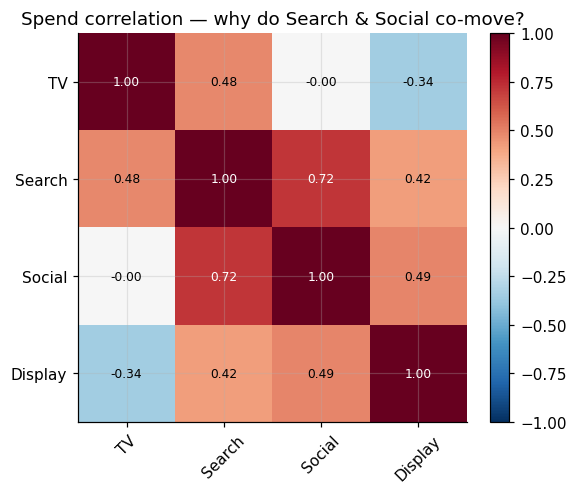

Search–Social spend correlation: 0.72
Not collinear enough to be unidentifiable on its own (stress_03 territory starts ~0.9),
but it begs a question: WHY do two separately-planned channels co-move? Keep reading.


In [3]:
# Check 3 — channel-spend collinearity.
corr = spend.corr()
fig, ax = plt.subplots(figsize=(5.4, 4.6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for (i, j), v in np.ndenumerate(corr.values):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
            color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, fraction=0.046)
ax.set_title("Spend correlation — why do Search & Social co-move?")
plt.tight_layout(); plt.show()
print(f"Search–Social spend correlation: {corr.loc['Search','Social']:.2f}")
print("Not collinear enough to be unidentifiable on its own (stress_03 territory starts ~0.9),")
print("but it begs a question: WHY do two separately-planned channels co-move? Keep reading.")

,"corr(spend, sales) «the dashboard number»","corr(spend, demand proxy)"
TV,0.294,0.234
Search,0.852,0.932
Social,0.690,0.890
Display,0.522,0.561


corr(demand proxy, sales) = 0.86  <- the proxy is a strong driver of the KPI


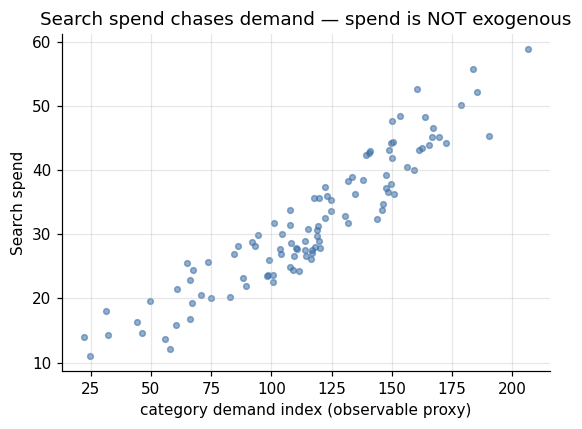

In [4]:
# Check 4 — the demand-chasing screen: the single highest-value table in MMM EDA.
mirage = pd.DataFrame({
    "corr(spend, sales)  «the dashboard number»":
        {c: np.corrcoef(spend[c], y)[0, 1] for c in CHANNELS},
    "corr(spend, demand proxy)":
        {c: np.corrcoef(spend[c], proxy)[0, 1] for c in CHANNELS},
}).loc[CHANNELS].round(3)
display(mirage)
print(f"corr(demand proxy, sales) = {np.corrcoef(proxy, y)[0,1]:.2f}  "
      "<- the proxy is a strong driver of the KPI")
assert mirage.loc["Search", "corr(spend, sales)  «the dashboard number»"] > 0.8
assert mirage.loc["Search", "corr(spend, demand proxy)"] > 0.9
fig, ax = plt.subplots(figsize=(5.2, 4))
ax.scatter(proxy, spend["Search"], s=14, alpha=0.55, color=SKY)
ax.set(xlabel="category demand index (observable proxy)", ylabel="Search spend",
       title="Search spend chases demand — spend is NOT exogenous")
plt.tight_layout(); plt.show()

**Decision point #1 — and it arrives before any model.** Search's spend
correlates ~0.85 with sales (a dashboard would call it the star channel) *and*
~0.93 with the category-demand index. That second number poisons the first:
when spend chases demand, `corr(spend, sales)` measures the *bidding rule*, not
the ad. A naive correlation far above any plausible ROAS — or far below it — is
a confounding tell, not a performance read; the analyst can say that much from
the table alone. This also answers Check 3: Search and Social co-move because
they chase the *same* demand signal, which is worse than ordinary collinearity —
they're collinear *with a confounder*.

> **🔭 GRADER'S BOX** — the inversion is even crueler than the analyst can know:
> TV has the *lowest* naive correlation (~0.29) and the *highest* true ROAS
> (~2.1), while Search pairs the highest correlation with one of the lowest true
> ROAS. The dashboard ranking is the truth ranking almost exactly reversed.

The pivot is mandatory, not optional: the demand proxy goes into the model as a
control. Hold that thought for Stage 1, where we deliberately fit without it —
because in real life the proxy is the column nobody exported.

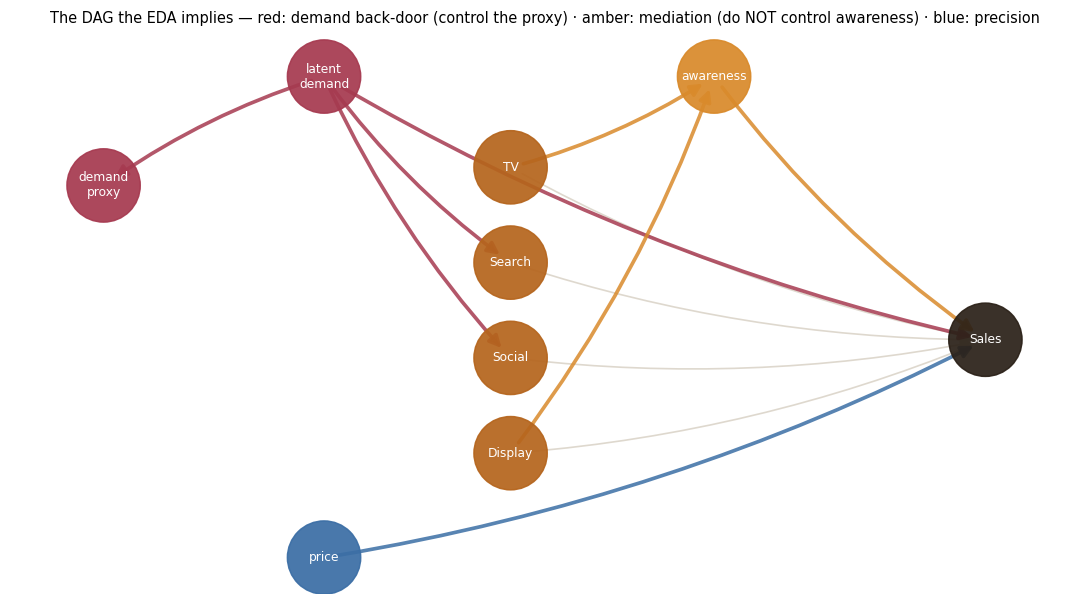

In [5]:
# Check 5 — candidate controls & their causal roles (the DAG).
import networkx as nx
G = nx.DiGraph()
for c in CHANNELS:
    G.add_node(c, kind="media"); G.add_edge(c, "Sales", kind="media")
G.add_node("Sales", kind="kpi")
G.add_node("latent\ndemand", kind="confounder")
G.add_node("demand\nproxy", kind="confounder")
G.add_node("awareness", kind="mediator")
G.add_node("price", kind="precision")
for ch in ["Search", "Social"]:
    G.add_edge("latent\ndemand", ch, kind="confound")
G.add_edge("latent\ndemand", "Sales", kind="confound")
G.add_edge("latent\ndemand", "demand\nproxy", kind="confound")
for ch in ["TV", "Display"]:
    G.add_edge(ch, "awareness", kind="mediate")
G.add_edge("awareness", "Sales", kind="mediate")
G.add_edge("price", "Sales", kind="precision")

pos = {"latent\ndemand": (-1.3, 2.9), "demand\nproxy": (-2.6, 1.7),
       "awareness": (1.0, 2.9), "Sales": (2.6, 0.0), "price": (-1.3, -2.4)}
for i, c in enumerate(CHANNELS):
    pos[c] = (-0.2, 1.9 - i * 1.05)
nkind = {"media": ACCENT, "kpi": INK, "confounder": BERRY,
         "mediator": AMBER, "precision": SKY}
ekind = {"media": "#d9d2c6", "confound": BERRY, "mediate": AMBER, "precision": SKY}
fig, ax = plt.subplots(figsize=(10, 5.6))
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2300,
                       node_color=[nkind[G.nodes[n]["kind"]] for n in G], alpha=0.93)
for k, col in ekind.items():
    es = [(u, v) for u, v, d in G.edges(data=True) if d["kind"] == k]
    nx.draw_networkx_edges(G, pos, edgelist=es, ax=ax, edge_color=col,
                           width=2.4 if k != "media" else 1.1, alpha=0.85,
                           arrowsize=16, connectionstyle="arc3,rad=0.08")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color="white")
ax.set_title("The DAG the EDA implies — red: demand back-door (control the proxy) · "
             "amber: mediation (do NOT control awareness) · blue: precision", fontsize=9.5)
ax.axis("off"); plt.tight_layout(); plt.show()

**Causal-role classification** (the walkthrough §1.6 method, condensed):

| candidate | evidence | role | treatment |
|---|---|---|---|
| `category_demand_index` | correlates with spend (Search 0.93) **and** sales (0.86) | **confounder** | **must include, don't shrink** |
| `price` | relates to KPI, not spend | precision control | include |
| `awareness` (survey) | brand tracker; *built by* TV/Display by design | **mediator** | **exclude as control** — model it explicitly or lose TV/Display's effect |
| (none observed) | — | collider | — |

One honest caveat the tame walkthrough world didn't need: the "downstream of
media" *correlation* tell is weak here — TV's spend is so flat (CoV ≈ 0.11)
that `corr(TV spend, awareness)` is only ~0.27. The mediator classification
comes from **institutional knowledge** (awareness is what TV is *bought to do*),
not from a correlation screen. The DAG is a statement of beliefs, and EDA can
only partially audit it.

**Stage 0 scorecard** — visible *before* sampling: demand confounding on
Search/Social (the stress_03 killer), unidentifiable TV/Display (low CoV),
a mediation pathway to handle (stress_04), and a clean outlier screen
(stress_01 ruled out).

> **🔭 GRADER'S BOX** — what no EDA could see: the true saturation curve is a
> Hill function, not the default logistic (the core model *can* fit Hill since
> the 2026-06-10 fix, but nothing in the data volunteers that you should ask),
> and Cold Brew cannibalizes Original each summer (invisible in a single-KPI
> view). Hold both: they come back at Stage 3b.

---
# Stage 1 — The naive fit (what actually gets shipped)

Now we do what the deadline does: fit the default model on the data as pulled —
KPI, four spend columns, the `price` control. **No demand proxy** (nobody
exported it), default blend adstock, default logistic saturation, default
priors. Fast settings (numpyro, 400×400, 2 chains) — the same arc holds at
production settings; the recorded matrix row used 500×500 PYMC.

The helper below is the series' standard grading rig: fit, then score every
channel's ROAS and contribution against the known truth, with 90% HDIs. Voice
discipline: in everything it prints, the `true ...` / `contrib err` / `true in
90% HDI` columns and any `[grader]`-prefixed line belong to the grader; the
analyst gets the estimates, the intervals, and the sampler diagnostics.

In [6]:
from mmm_framework.config import InferenceMethod, ModelConfig
from mmm_framework.model import BayesianMMM, TrendConfig, TrendType
from mmm_framework.analysis import MMMAnalyzer

# Importing pymc installs its own handlers; re-quiet so chatter stays out.
for _n in ("pymc", "pymc.sampling", "numpyro", "jax", "arviz", "pytensor"):
    _lg = logging.getLogger(_n); _lg.setLevel(logging.ERROR); _lg.propagate = False

DRAWS, CHAINS = 400, 2
STAGES = {}   # label -> {"model", "fit", "tab", "secs"}

def fit_stage(label, *, control_demand, parametric=False, hill=False, experiments=None):
    "Fit one staged model on the Aurora panel and grade it against the truth."
    panel = aurora.base_panel(control_demand=control_demand)
    if hill:  # per-channel Hill saturation — honored by the core model since 2026-06-10
        from mmm_framework.config import SaturationConfig
        for _mc in panel.config.media_channels:
            _mc.saturation = SaturationConfig.hill()
    cfg = ModelConfig(
        inference_method=InferenceMethod.BAYESIAN_NUMPYRO,
        n_chains=CHAINS, n_draws=DRAWS, n_tune=DRAWS, optim_seed=0,
        use_parametric_adstock=parametric,
    )
    m = BayesianMMM(panel, cfg, TrendConfig(type=TrendType.LINEAR),
                    experiments=experiments)
    t0 = time.perf_counter()
    with quiet():
        fit = m.fit(random_seed=0)
    secs = round(time.perf_counter() - t0, 1)
    with quiet():
        roi = MMMAnalyzer(m).compute_channel_roi(random_seed=0).set_index("Channel")
    tab = pd.DataFrame({
        "est ROAS": roi["ROI"],
        "ROAS lo": roi["Contribution HDI Low"] / roi["Total Spend"],
        "ROAS hi": roi["Contribution HDI High"] / roi["Total Spend"],
        "true ROAS": TRUE_ROAS,
        "contrib err": (roi["Total Contribution"] - TRUE_CONTRIB) / TRUE_CONTRIB,
    }).loc[CHANNELS]
    tab["true in 90% HDI"] = np.where(
        (tab["ROAS lo"] <= tab["true ROAS"]) & (tab["true ROAS"] <= tab["ROAS hi"]),
        "✓", "✗")
    STAGES[label] = {"model": m, "fit": fit, "tab": tab, "secs": secs}
    print(f"[{label}]  fit {secs}s   r-hat max {fit.diagnostics['rhat_max']:.3f}   "
          f"divergences {fit.diagnostics['divergences']}   "
          f"| [grader] med|contrib err| {tab['contrib err'].abs().median():.0%}")
    show = tab.copy()
    show["contrib err"] = show["contrib err"].map("{:+.0%}".format)
    return m, fit, show.round(2)

m1, f1, show1 = fit_stage("Stage 1 — naive", control_demand=False)
display(show1)

  0%|          | 0/800 [00:00<?, ?it/s]

  0%|          | 0/800 [00:00<?, ?it/s]

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Output()

Output()

Output()

Output()

[Stage 1 — naive]  fit 11.0s   r-hat max 1.020   divergences 0   | [grader] med|contrib err| 95%


,est ROAS,ROAS lo,ROAS hi,true ROAS,contrib err,true in 90% HDI
TV,0.21,0.01,0.63,2.14,-90%,✗
Search,2.58,0.69,4.36,0.66,+289%,✗
Social,0.97,0.04,2.76,0.49,+99%,✓
Display,0.49,0.02,1.48,2.11,-77%,✗


In [7]:
t1 = STAGES["Stage 1 — naive"]["tab"]

# ANALYST-VISIBLE: the model's ROAS ranking is the EDA mirage ranking, exactly.
est_rank = list(t1["est ROAS"].sort_values(ascending=False).index)
mirage_rank = list(mirage.iloc[:, 0].sort_values(ascending=False).index)
print(f"Ranking by est ROAS:               {est_rank}")
print(f"Ranking by naive corr(spend,sales): {mirage_rank}")
assert est_rank == mirage_rank, "the naive fit should reproduce the dashboard mirage"
print("The model reproduces the dashboard's correlation ranking exactly — the very table the")
print("EDA flagged as demand-poisoned (Decision point #1). A converged Bayesian model that")
print("hands back the confounded dashboard with credible intervals on it has added rigor to")
print("the WRONG quantity. That is the analyst's first reason for suspicion, no truth needed.")

# GRADER: how wrong is it, really?
assert t1.loc["Search", "est ROAS"] > 3 * TRUE_ROAS["Search"], "Search should be wildly overstated"
assert t1.loc["TV", "est ROAS"] < 0.5 * TRUE_ROAS["TV"], "TV should be wildly understated"
assert t1.loc["Search", "true in 90% HDI"] == "✗"
print(f"\n[grader] Search: est {t1.loc['Search','est ROAS']:.2f} vs true {TRUE_ROAS['Search']:.2f}  "
      f"({t1.loc['Search','est ROAS']/TRUE_ROAS['Search']:.1f}x overstated, truth outside the 90% HDI)")
print(f"[grader] TV:     est {t1.loc['TV','est ROAS']:.2f} vs true {TRUE_ROAS['TV']:.2f}  "
      f"({1-t1.loc['TV','est ROAS']/TRUE_ROAS['TV']:.0%} of a real brand engine erased)")
print(f"[grader] Ranking by TRUE ROAS: {list(TRUE_ROAS.loc[CHANNELS].sort_values(ascending=False).index)}"
      " — the est ranking, almost exactly reversed.")

Ranking by est ROAS:               ['Search', 'Social', 'Display', 'TV']
Ranking by naive corr(spend,sales): ['Search', 'Social', 'Display', 'TV']
The model reproduces the dashboard's correlation ranking exactly — the very table the
EDA flagged as demand-poisoned (Decision point #1). A converged Bayesian model that
hands back the confounded dashboard with credible intervals on it has added rigor to
the WRONG quantity. That is the analyst's first reason for suspicion, no truth needed.

[grader] Search: est 2.58 vs true 0.66  (3.9x overstated, truth outside the 90% HDI)
[grader] TV:     est 0.21 vs true 2.14  (90% of a real brand engine erased)
[grader] Ranking by TRUE ROAS: ['TV', 'Display', 'Search', 'Social'] — the est ranking, almost exactly reversed.


## Reading the alarms — what "loud" actually looks like

When this world was first recorded (PYMC 500×500, code state 2026-06-08) it
was the one *loud* row in the table: r-hat 1.11, **108 divergences**. Read
what our fast fit just printed: a divergence or two, r-hat hovering at ~1.01,
and (in the sampler logs) low-ESS warnings. And the matrix row itself, when
re-recorded on later code (same config, same seed), collapsed to an order of
magnitude quieter — the cell below prints the current recording so you can
see today's volume; the siren did not survive a code revision, and honesty
requires saying so. The sampler's volume depends on sampler, seed, and code
version; the wrongness (which only the grader's archive can measure) doesn't.

That is the two-sided lesson the capstone needs:

1. **When alarms fire, they are a gift — don't bribe them.** The reflex of
   bumping `target_accept` to 0.99 until the divergences stop is treating the
   smoke detector, not the fire. Divergences in an MMM usually mean the
   posterior has a pathological region *because the model is fighting the data*
   — here, four violations at once. Diagnose before re-tuning.
2. **When alarms don't fire, you've learned almost nothing.** While authoring
   this we measured naive variants of this same fit at **zero** divergences —
   still ~4-8× wrong on Search depending on the defaults of the day. And every
   silent-failure row in the matrix had r-hat ≤1.02 and zero divergences.
   Convergence diagnostics check the *sampler*, never the *attribution* —
   stress_00's founding lesson.

**Decision point #2:** whichever volume you got — a converged-looking fit whose
answer mirrors a correlation table you already know is confounded, or a noisy
fit with warnings — you do not ship. You triage.

In [8]:
# The recorded full-fidelity row (tests/synth/results/stress_matrix.json), for the record:
rec_path = pathlib.Path("../tests/synth/results/stress_matrix.json")
row = next(r for r in json.loads(rec_path.read_text()) if r["name"] == "aurora_kitchen_sink")
print("Recorded stress-matrix row (PYMC 500x500x2, seed 0, re-recorded 2026-06-10):")
print(f"  med|err| {row['median_abs_rel_error']:.0%}   worst {row['max_abs_rel_error']:+.0%}   "
      f"coverage {row['coverage_rate']:.0%}")
print(f"  r-hat {row['rhat_max']:.2f}   divergences {row['divergences']}")
print(f"\nThis notebook's naive fit (numpyro {DRAWS}x{DRAWS}x{CHAINS}, current code):")
f1d = STAGES['Stage 1 — naive']['fit'].diagnostics
print(f"  med|err| {t1['contrib err'].abs().median():.0%}   "
      f"r-hat {f1d['rhat_max']:.2f}   divergences {f1d['divergences']}")
print("\nAn earlier recording of this row (code state 2026-06-08) logged r-hat 1.11 and")
print("108 divergences on this same world — compare the re-recorded row above. Same")
print("model, same data, same wrongness; alarm volume varies by sampler, seed, and")
print("code version. A decision rule that depends on the sampler's mood is not a")
print("decision rule.")

Recorded stress-matrix row (PYMC 500x500x2, seed 0, re-recorded 2026-06-10):
  med|err| 92%   worst +223%   coverage 25%
  r-hat 1.02   divergences 11

This notebook's naive fit (numpyro 400x400x2, current code):
  med|err| 95%   r-hat 1.02   divergences 0

An earlier recording of this row (code state 2026-06-08) logged r-hat 1.11 and
108 divergences on this same world — compare the re-recorded row above. Same
model, same data, same wrongness; alarm volume varies by sampler, seed, and
code version. A decision rule that depends on the sampler's mood is not a
decision rule.


---
# Stage 2 — Triage with the stress_00 toolkit

Don't re-tune; diagnose. The toolkit from
[stress_00](stress_00_the_rosy_picture.ipynb): parameter learning
(prior→posterior contraction/overlap/shift), the unobserved-confounding
robustness value (RV), and the PPC — each symptom mapped to a suspect.

In [9]:
# Parameter learning: which parameters did the data actually inform — and which
# is it FIGHTING the prior over?
with quiet():
    learn = m1.compute_parameter_learning(prior_samples=600, random_seed=0)
cols = ["parameter", "prior_mean", "post_mean", "contraction", "overlap", "shift_z", "verdict"]
media_rows = learn[learn["parameter"].str.startswith(("beta_", "adstock", "sat_lam"))]
display(media_rows[cols].round(2).reset_index(drop=True))
bs = learn.set_index("parameter")
assert bs.loc["beta_Search", "contraction"] < 0, "expect prior-data CONFLICT on beta_Search"
print(f"beta_Search: contraction {bs.loc['beta_Search','contraction']:+.2f} (NEGATIVE: the posterior is")
print(f"  WIDER than the prior), shift_z {bs.loc['beta_Search','shift_z']:+.1f} (dragged ~"
      f"{abs(bs.loc['beta_Search','shift_z']):.0f} prior-SDs upward), overlap {bs.loc['beta_Search','overlap']:.2f}.")
print("  -> prior-data CONFLICT: something in the data demands an implausibly huge Search effect.")
print("     Honest priors + confounded data = the conflict shows up HERE first.")
print(f"adstock parameters: verdicts {list(media_rows[media_rows['parameter'].str.startswith('adstock')]['verdict'])}")
print("  -> carryover essentially unlearned (prior-dominated): with four violations at once the")
print("     data cannot pin the response shape. (Negative contraction =/= importance — see stress_00.)")

,parameter,prior_mean,post_mean,contraction,overlap,shift_z,verdict
0,beta_Search,1.47,3.53,-1.17,0.39,2.03,relocated
1,beta_Social,1.45,1.65,-0.48,0.84,0.21,weak
2,adstock_Display,0.51,0.45,-0.16,0.79,-0.25,weak
3,adstock_Social,0.51,0.39,-0.00,0.73,-0.56,weak
4,adstock_TV,0.50,0.45,0.10,0.84,-0.21,moderate
5,beta_Display,1.58,1.09,0.31,0.75,-0.47,moderate
6,adstock_Search,0.50,0.23,0.36,0.47,-1.16,moderate
7,beta_TV,1.55,1.00,0.48,0.73,-0.53,moderate
8,sat_lam_Social,1.99,1.23,0.62,0.77,-0.39,strong
9,sat_lam_Search,2.00,2.24,0.72,0.64,0.11,strong


beta_Search: contraction -1.17 (NEGATIVE: the posterior is
  WIDER than the prior), shift_z +2.0 (dragged ~2 prior-SDs upward), overlap 0.39.
  -> prior-data CONFLICT: something in the data demands an implausibly huge Search effect.
     Honest priors + confounded data = the conflict shows up HERE first.
adstock parameters: verdicts ['weak', 'weak', 'moderate', 'moderate']
  -> carryover essentially unlearned (prior-dominated): with four violations at once the
     data cannot pin the response shape. (Negative contraction =/= importance — see stress_00.)


In [10]:
# RV + PPC (cheap validation config, as in tests/synth/harness.py).
from mmm_framework.validation import ModelValidator, ValidationConfigBuilder
vcfg = (ValidationConfigBuilder().silent().without_residuals()
        .without_channel_diagnostics().with_unobserved_confounding().build())
vcfg.run_model_comparison = False
vcfg.run_ppc = True
with quiet():
    vsum = ModelValidator(m1).validate(vcfg)
rv = {c.channel: round(float(c.robustness_value), 2)
      for c in vsum.unobserved_confounding.channels}
print("Robustness values (RV — share of residual variance an unobserved confounder")
print("would need to explain, jointly with spend, to nullify the channel):", rv)
print("Channels auto-flagged fragile:", vsum.unobserved_confounding.fragile_channels or "none")
print(f"PPC: overall pass = {vsum.ppc.overall_pass}, problems = {vsum.ppc.problematic_checks}")
print(f"Formal convergence verdict: converged = {vsum.convergence.converged} "
      f"(r-hat {vsum.convergence.rhat_max:.3f}, divergences {vsum.convergence.divergences})")

Output()

Robustness values (RV — share of residual variance an unobserved confounder
would need to explain, jointly with spend, to nullify the channel): {'TV': 0.13, 'Search': 0.21, 'Social': 0.13, 'Display': 0.12}
Channels auto-flagged fragile: none
PPC: overall pass = True, problems = []
Formal convergence verdict: converged = False (r-hat 1.020, divergences 0)


Output()

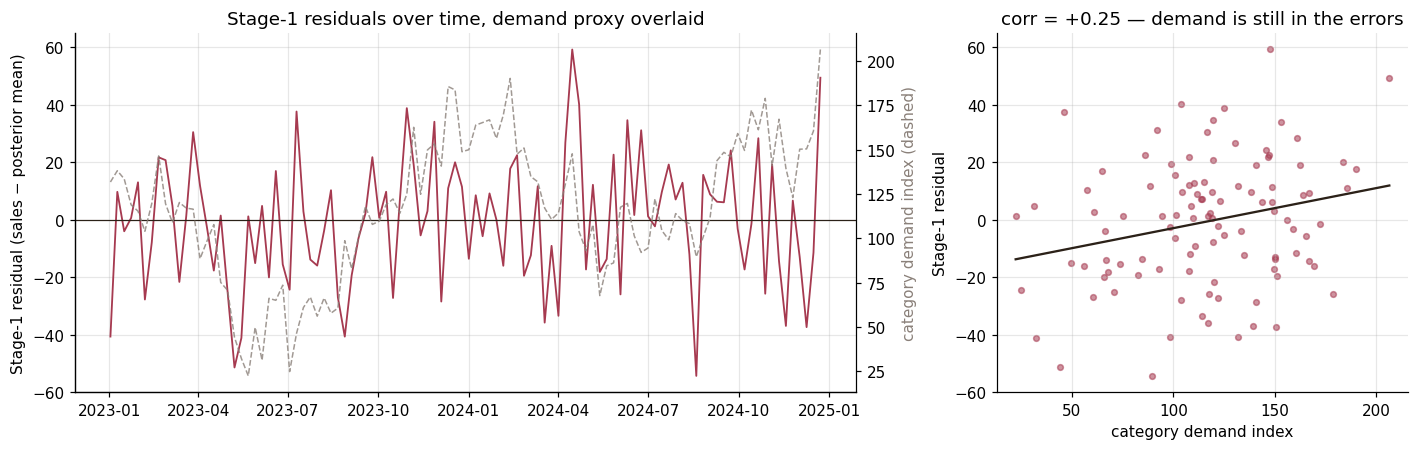

corr(Stage-1 residuals, demand proxy) = +0.25
ANALYST-VISIBLE: a column the model never saw predicts the model's errors. Together
with the beta_Search prior-data conflict, that is two independent observable fingers
pointing at the same omitted variable. No truth access required.


In [11]:
# The cheapest triage check of all: residuals vs a driver you HAVE but didn't use.
# The proxy is sitting in the EDA (Check 4) — the Stage-1 model just omitted it.
with quiet():
    pred1 = m1.predict(return_original_scale=True, hdi_prob=0.90, random_seed=0)
STAGES["Stage 1 — naive"]["pred"] = pred1          # reused by the fit-grid later
resid1 = y.to_numpy() - pred1.y_pred_mean
r_resid = np.corrcoef(resid1, proxy)[0, 1]

fig, (axl, axr) = plt.subplots(1, 2, figsize=(13, 4.2),
                               gridspec_kw={"width_ratios": [1.9, 1]})
axl.plot(aurora.weeks, resid1, color=BERRY, lw=1.2)
axl.axhline(0, color=INK, lw=0.8)
ax2 = axl.twinx()
ax2.plot(aurora.weeks, proxy, color=MUTED, lw=1.0, ls="--", alpha=0.8)
ax2.set_ylabel("category demand index (dashed)", color=MUTED)
ax2.grid(False); ax2.spines["right"].set_visible(True)
axl.set_ylabel("Stage-1 residual (sales − posterior mean)")
axl.set_title("Stage-1 residuals over time, demand proxy overlaid")
b, a = np.polyfit(proxy, resid1, 1)
xs = np.linspace(proxy.min(), proxy.max(), 50)
axr.scatter(proxy, resid1, s=14, alpha=0.55, color=BERRY)
axr.plot(xs, a + b * xs, color=INK, lw=1.5)
axr.set(xlabel="category demand index", ylabel="Stage-1 residual",
        title=f"corr = {r_resid:+.2f} — demand is still in the errors")
plt.tight_layout(); plt.show()

assert r_resid > 0.12, "naive residuals should still carry demand structure"
print(f"corr(Stage-1 residuals, demand proxy) = {r_resid:+.2f}")
print("ANALYST-VISIBLE: a column the model never saw predicts the model's errors. Together")
print("with the beta_Search prior-data conflict, that is two independent observable fingers")
print("pointing at the same omitted variable. No truth access required.")

**Reading the triage** — symptom by symptom (this drafts the decision table we
finalize at the end):

| symptom we just measured | likely cause | the suspect here |
|---|---|---|
| `beta_Search` **negative contraction** + huge upward `shift_z` | prior-data conflict — data demanding an effect the prior thinks absurd | demand confounding inflating Search (EDA: corr(spend, proxy) ≈ 0.93) |
| adstock/shape params **prior-dominated** | response shape unidentified — equifinality | flat TV/Display spend + form misspec stacked on confounding |
| RV not flagging anything, Search's RV the *highest* | RV asks "how strong a confounder *would it take*?" — it can't know one exists | the proxy correlates 0.86 with sales: a confounder of exactly that strength **does** exist. RV must be compared to plausible confounders, not read as a green light |
| **PPC passes** | PPC checks *fit to the joint outcome*, and demand is doing the predicting | the model predicts sales beautifully — *through the confounder*. stress_00's crying-wolf inverse: green PPC certifies nothing about attribution |
| residuals correlate with an **available-but-unused** driver (~0.25 here) | omitted-variable structure the model routed into media betas | the proxy from the EDA belongs in the model — the errors say so directly |
| divergences/r-hat flicker | posterior geometry strained by misspec | all four violations at once |

Triage verdict: the loudest, most specific signal is the **prior-data conflict
on the channel whose spend chases demand**. The first pivot is structural, and
the EDA already told us which: close the back-door.

---
# Stage 3 — Structural pivots, in deliberate order

One pivot at a time — each chosen from a measured, analyst-visible symptom,
never from a disliked answer; that is the discipline that separates *modeling*
from *knob-turning*. (The grader scores the truth-gap after each, so the
reader can watch what each pivot actually bought.)

## Pivot (a): close the back-door — add the demand proxy as a control

In [12]:
m2, f2, show2 = fit_stage("Stage 3a — + demand control", control_demand=True)
display(show2)
t2 = STAGES["Stage 3a — + demand control"]["tab"]
drop = 1 - t2.loc["Search", "est ROAS"] / t1.loc["Search", "est ROAS"]
assert t2.loc["Search", "est ROAS"] < 0.75 * t1.loc["Search", "est ROAS"], "control should bite"
# Residual overstatement remains, but the bigger tell is the interval: after
# conditioning on a proxy that correlates ~0.93 with Search's spend, there is
# almost no independent variation left — the model's honest answer is "wide".
assert t2.loc["Search", "contrib err"] > 0.20, "residual Search overstatement should remain"
rel_w = (t2.loc["Search", "ROAS hi"] - t2.loc["Search", "ROAS lo"]) / t2.loc["Search", "est ROAS"]
assert rel_w > 1.0, "Search interval should be huge after conditioning on the collinear proxy"

# ANALYST-VISIBLE: one spec choice moved the headline channel by two-thirds,
# and the interval that came back is too wide to act on.
print(f"Search ROAS: {t1.loc['Search','est ROAS']:.2f}  ->  {t2.loc['Search','est ROAS']:.2f}  "
      f"(-{drop:.0%} from ONE spec change — a number that spec-sensitive is not a measurement)")
print(f"Search 90% interval: [{t2.loc['Search','ROAS lo']:.2f}, {t2.loc['Search','ROAS hi']:.2f}]"
      f" — {rel_w:.1f}x the estimate; it contains 'kill the channel' and 'double it'.")
print(f"TV/Display barely move ({t1.loc['TV','est ROAS']:.2f}->{t2.loc['TV','est ROAS']:.2f} / "
      f"{t1.loc['Display','est ROAS']:.2f}->{t2.loc['Display','est ROAS']:.2f}), still with "
      "intervals several times their estimates — the EDA's flat-spend flag (CoV ~0.11) stands.")

# GRADER: was the move toward the truth, and was it enough?
print(f"\n[grader] Search residual contribution error {t2.loc['Search','contrib err']:+.0%} "
      f"(true ROAS {TRUE_ROAS['Search']:.2f}): the pivot went the right way and stopped well short.")
print(f"[grader] TV/Display contribution errors: {t2.loc['TV','contrib err']:+.0%} / "
      f"{t2.loc['Display','contrib err']:+.0%} — the mediated channels did not move toward truth at all.")

  0%|          | 0/800 [00:00<?, ?it/s]

  0%|          | 0/800 [00:00<?, ?it/s]

Output()

Output()

Output()

Output()

Output()

[Stage 3a — + demand control]  fit 9.0s   r-hat max 1.011   divergences 0   | [grader] med|contrib err| 65%


,est ROAS,ROAS lo,ROAS hi,true ROAS,contrib err,true in 90% HDI
TV,0.38,0.02,1.09,2.14,-82%,✗
Search,0.99,0.06,2.44,0.66,+49%,✓
Social,0.80,0.03,2.30,0.49,+64%,✓
Display,0.70,0.03,2.15,2.11,-67%,✓


Search ROAS: 2.58  ->  0.99  (-62% from ONE spec change — a number that spec-sensitive is not a measurement)
Search 90% interval: [0.06, 2.44] — 2.4x the estimate; it contains 'kill the channel' and 'double it'.
TV/Display barely move (0.21->0.38 / 0.49->0.70), still with intervals several times their estimates — the EDA's flat-spend flag (CoV ~0.11) stands.

[grader] Search residual contribution error +49% (true ROAS 0.66): the pivot went the right way and stopped well short.
[grader] TV/Display contribution errors: -82% / -67% — the mediated channels did not move toward truth at all.


**The pivot moved the answer — and the analyst can see it wasn't enough.**
Adding the proxy collapsed Search's ROAS by roughly two-thirds, exactly the
direction the DAG predicted. What the analyst reads off the new fit, with no
truth access:

- **The interval is the result.** Search's 90% ROAS interval now spans roughly
  [0.1, 2.4] — it contains "cut the channel to zero" and "the channel pays for
  itself twice over". Whatever the midpoint says, *this is not a number you can
  take to a budget meeting*.
- **The estimate is spec-sensitive.** One defensible spec choice (include the
  control the DAG demands) moved the headline channel by ~60%. When the spec
  moves the number more than the posterior width of anything else in the table,
  the spec — not the data — is choosing the answer.
- **The mediated channels are implausible on their face.** TV has been bought
  at ~$55k/week for two years; the model says ~0.4 ROAS with an interval
  several times that. The EDA already said why no observational read can do
  better: CoV ≈ 0.11 — there is almost no spend variation to learn from — and
  the DAG routes TV's effect through awareness, a pathway this single-equation
  model can only smear into the baseline.

Why does controlling not finish the job? **Controlled ≠ identified.** Search's
spend correlates ~0.93 with the proxy we just added: after conditioning on it,
there is almost no *independent* Search variation left for the likelihood to
learn from. The model now splits a shared signal between `beta_Search` and the
control coefficient, and the split is decided largely by the priors and the
noise.

> **🔭 GRADER'S BOX** — the analyst's reading is right: the pivot went the
> correct direction and stopped short. Search keeps a ~+50% contribution
> overstatement (truth inside the huge interval, far from the midpoint), and
> TV/Display stay ~-65–85% under-credited. This is stress_03's
> `confounding_controlled` row (over-credited *with* the confounder controlled,
> all diagnostics green) playing out on the kitchen-sink world. A control
> closes the back-door; it does not manufacture identifying variation.

## Pivot (b): probe the response form — and read the *sensitivity*, not the hope

The analyst cannot see the true response curve (no EDA shows it, and the Stage-2
learning table said the shape parameters are mostly prior-dominated). What the
analyst *can* do is the stress_01 discipline: refit under a deliberately
different, defensible response family — in-graph parametric adstock plus
per-channel Hill saturation (`SaturationConfig.hill()`, available since the
2026-06-10 fix) — and read the result as a **spec-sensitivity experiment**:

- If the estimates *hold still*, the data was pinning them despite the form.
- If they *move materially* without any visible fit improvement, then the form
  was doing the talking — and no single spec's midpoint deserves belief.

Measure it honestly:

In [13]:
m3, f3, show3 = fit_stage("Stage 3b — + richer response form", control_demand=True,
                          parametric=True, hill=True)
display(show3)
t3 = STAGES["Stage 3b — + richer response form"]["tab"]
cmp = pd.DataFrame({
    "3a est ROAS": t2["est ROAS"], "3b est ROAS": t3["est ROAS"],
    "true": TRUE_ROAS.loc[CHANNELS],
    "3a |contrib err|": t2["contrib err"].abs(), "3b |contrib err|": t3["contrib err"].abs(),
}).round(2)
display(cmp)
med3a = t2["contrib err"].abs().median(); med3b = t3["contrib err"].abs().median()

# ANALYST-VISIBLE: the sensitivity readout. Compare what each spec lever moved.
form_delta = ((t3["est ROAS"] - t2["est ROAS"]).abs() / t2["est ROAS"])
ctrl_delta = ((t2["est ROAS"] - t1["est ROAS"]).abs() / t1["est ROAS"])
print("Spec-sensitivity readout (relative move in est ROAS):")
print("  response-form change (3a -> 3b): " +
      ", ".join(f"{c} {form_delta[c]:.0%}" for c in CHANNELS))
print(f"  demand-control change (1 -> 3a): Search {ctrl_delta['Search']:.0%} "
      f"(and TV {ctrl_delta['TV']:.0%} relative on a tiny base)")
assert form_delta.max() < 0.30, "form change should move estimates only modestly"
assert ctrl_delta["Search"] > 0.40, "the control was the lever that moved the answer"
print("A much richer response family moved every estimate by ~10% or less and (as the")
print("fit-quality grid below will show) improved nothing the analyst can measure.")
print("The numbers are being chosen by identification, not by curve shape.")

# GRADER: did the 'better' form help against the truth?
print(f"\n[grader] med|err|: 3a {med3a:.0%} -> 3b {med3b:.0%}  (the headline got "
      + ("WORSE" if med3b > med3a else "barely better") + ")")
print(f"[grader] Search: {t2.loc['Search','est ROAS']:.2f} -> {t3.loc['Search','est ROAS']:.2f} "
      f"(true {TRUE_ROAS['Search']:.2f});  Social: {t2.loc['Social','est ROAS']:.2f} -> "
      f"{t3.loc['Social','est ROAS']:.2f} (true {TRUE_ROAS['Social']:.2f})")
# The form pivot must not be allowed to claim victory: no material headline gain.
assert med3b > 0.8 * med3a, "true-form pivot should NOT materially fix a confounded world"
assert t3.loc["TV", "contrib err"] < -0.5, "the mediated channel stays destroyed"

  0%|          | 0/800 [00:00<?, ?it/s]

  0%|          | 0/800 [00:00<?, ?it/s]

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Output()

...

Output()

[Stage 3b — + richer response form]  fit 10.8s   r-hat max 1.017   divergences 0   | [grader] med|contrib err| 71%


,est ROAS,ROAS lo,ROAS hi,true ROAS,contrib err,true in 90% HDI
TV,0.36,0.05,0.97,2.14,-83%,✗
Search,1.09,0.27,2.05,0.66,+64%,✓
Social,0.86,0.12,2.02,0.49,+76%,✓
Display,0.72,0.11,1.92,2.11,-66%,✗


,3a est ROAS,3b est ROAS,true,3a |contrib err|,3b |contrib err|
TV,0.38,0.36,2.14,0.82,0.83
Search,0.99,1.09,0.66,0.49,0.64
Social,0.80,0.86,0.49,0.64,0.76
Display,0.70,0.72,2.11,0.67,0.66


Spec-sensitivity readout (relative move in est ROAS):
  response-form change (3a -> 3b): TV 7%, Search 10%, Social 7%, Display 3%
  demand-control change (1 -> 3a): Search 62% (and TV 85% relative on a tiny base)
A much richer response family moved every estimate by ~10% or less and (as the
fit-quality grid below will show) improved nothing the analyst can measure.
The numbers are being chosen by identification, not by curve shape.

[grader] med|err|: 3a 65% -> 3b 71%  (the headline got WORSE)
[grader] Search: 0.99 -> 1.09 (true 0.66);  Social: 0.80 -> 0.86 (true 0.49)


**The analyst's reading of the sensitivity experiment:** the form lever moved
every estimate by ~10% or less, the control lever moved the headline channel by
~60%, and nothing observable (fit, intervals, diagnostics) preferred one form
over the other. Conclusion an analyst can defend without truth access: *the
response form is not the binding constraint; these numbers are pinned — or not
pinned — by identification.* And remember what Stage 2 measured: the shape
parameters are mostly prior-dominated, so the "richer" form mostly bought new
knobs the data cannot turn. Don't over-credit a form change because one
channel's number moved toward your hopes; read the whole table.

> **🔭 GRADER'S BOX** — the punchline the analyst can never enjoy: pivot (b)
> handed the model the DGP's *exact* response family on both axes (geometric
> carryover, the very Hill curve the world uses) — and the truth-gap got
> slightly **worse** (med|err| ~65% → ~71%). Under unresolved confounding,
> form pivots **reshuffle the bias** among equifinal parameterizations
> (carryover ↔ saturation ↔ β trade off; math_01/math_05) rather than remove
> it. The fix stress_01 motivated is real *when form is the problem* (it cut
> that world's bias from ≈+40% to ≈+5%); here identification binds, and no
> functional form manufactures it.

## Pivot (c): acknowledge the mediation — and its limits

TV and Display still print sub-1 ROAS midpoints inside intervals several times
that size. The analyst's case that these reads are structurally untrustworthy
needs no truth: the DAG (institutional knowledge — awareness is what TV is
*bought to do*) routes their effect through a mediator this single-equation
model cannot see, and their spend is nearly flat (CoV ≈ 0.11), so the data
contains almost no experiment-like variation either way. Two honest statements:

1. The right *structural* model is a nested/mediation MMM with the awareness
   survey as the mediator outcome — that is
   [stress_04](stress_04_extension_traps.ipynb)'s subject, including the trap
   that an extension adds unidentifiable knobs when the mediator data is weak.
   We don't refit it here; the capstone's point is *when to reach for it*.
2. Even a perfect mediation model cannot conjure identification out of a CoV-0.11
   spend series. The EDA flagged TV/Display for experiments in Stage 0; nothing
   we've measured since changes that.

> **🔭 GRADER'S BOX** — the analyst's structural suspicion is exactly right:
> ~97–99% of TV/Display's true effect routes through awareness, and at Stage 3b
> they remain ~65–85% under-credited. The wide intervals are the model being
> honest about precisely this.

**Decision point #3:** the observational program has hit its **identification
ceiling**: the demand-chasers are controlled-but-collinear, the brand channels
are mediated-and-flat. More observational modeling from here is knob-turning.
The next dollar of effort buys more as a *randomized experiment* than as a
fifth structural variant.

---
# Stage 4 — The experiment

Aurora runs geo-holdout lift tests on the two cheapest-to-test channels —
Search and Social (always-on auction media: a clean two-month holdout reads out
fast). The tests measure ROAS over the experiment window; we fold each in as an
**in-graph likelihood term** on the model-implied ROAS estimand
(`add_experiment_calibration` / `experiments=`, route 2 of
[math_05](math_05_calibration.ipynb)) and refit. In this synthetic world the
"measured" values are the true ROAS values with a realistic standard error —
i.e., we simulate competently-run tests.

In [14]:
from mmm_framework.calibration import ExperimentMeasurement, ExperimentEstimand

window = (str(aurora.weeks[52].date()), str(aurora.weeks[90].date()))
experiments = [
    ExperimentMeasurement("Search", window, value=float(TRUE_ROAS["Search"]), se=0.07,
                          estimand=ExperimentEstimand.ROAS),
    ExperimentMeasurement("Social", window, value=float(TRUE_ROAS["Social"]), se=0.07,
                          estimand=ExperimentEstimand.ROAS),
]
print(f"experiment window: {window}")
print(f"measured ROAS: Search {TRUE_ROAS['Search']:.2f}±0.07, Social {TRUE_ROAS['Social']:.2f}±0.07")
m4, f4, show4 = fit_stage("Stage 4 — + experiments", control_demand=True,
                          parametric=True, hill=True, experiments=experiments)
display(show4)

experiment window: ('2024-01-01', '2024-09-23')
measured ROAS: Search 0.66±0.07, Social 0.49±0.07


  0%|          | 0/800 [00:00<?, ?it/s]

  0%|          | 0/800 [00:00<?, ?it/s]

There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


...

Output()

Output()

Output()

[Stage 4 — + experiments]  fit 11.6s   r-hat max 1.015   divergences 2   | [grader] med|contrib err| 31%


,est ROAS,ROAS lo,ROAS hi,true ROAS,contrib err,true in 90% HDI
TV,0.53,0.08,1.18,2.14,-75%,✗
Search,0.62,0.50,0.75,0.66,-6%,✓
Social,0.48,0.30,0.63,0.49,-2%,✓
Display,0.93,0.13,2.29,2.11,-56%,✓


In [15]:
t4 = STAGES["Stage 4 — + experiments"]["tab"]

# ANALYST-VISIBLE: the experiment readouts ARE ground truth for these two
# channels over this window — that is what randomization buys. After folding
# them in, look at what the analyst can now see: interval widths.
relw4 = ((t4["ROAS hi"] - t4["ROAS lo"]) / t4["est ROAS"]).round(2)
print("Post-calibration 90% intervals (analyst-visible):")
for c in CHANNELS:
    tag = "anchored to a randomized readout" if c in ("Search", "Social") \
        else "STILL unidentified — interval ~2x the estimate, spec-sensitive"
    print(f"  {c:8s} [{t4.loc[c,'ROAS lo']:.2f}, {t4.loc[c,'ROAS hi']:.2f}]  "
          f"(width/est {relw4[c]:.2f})  — {tag}")
assert relw4["Search"] < 0.9 and relw4["Social"] < 1.0, "calibrated channels should be tight"
assert relw4["TV"] > 1.5 and relw4["Display"] > 1.5, "uncalibrated channels stay wide"
print("Calibration is not contagious: anchoring Search/Social did nothing for TV/Display's")
print("widths. The Stage-0 test plan for the brand channels stands — that is the next buy.")

# GRADER: score the full arc.
assert abs(t4.loc["Search", "est ROAS"] - TRUE_ROAS["Search"]) < 0.25
assert abs(t4.loc["Social", "est ROAS"] - TRUE_ROAS["Social"]) < 0.25
assert t4.loc["Search", "true in 90% HDI"] == "✓" and t4.loc["Social", "true in 90% HDI"] == "✓"
assert t4["contrib err"].abs().median() < t1["contrib err"].abs().median()
print(f"\n[grader] Search: {t1.loc['Search','est ROAS']:.2f} (naive) -> "
      f"{t2.loc['Search','est ROAS']:.2f} (+control) -> {t3.loc['Search','est ROAS']:.2f} "
      f"(+form) -> {t4.loc['Search','est ROAS']:.2f} (+experiment)   true {TRUE_ROAS['Search']:.2f} ✓")
print(f"[grader] Social: {t1.loc['Social','est ROAS']:.2f} -> {t2.loc['Social','est ROAS']:.2f} -> "
      f"{t3.loc['Social','est ROAS']:.2f} -> {t4.loc['Social','est ROAS']:.2f}   "
      f"true {TRUE_ROAS['Social']:.2f} ✓")
print(f"[grader] med|contrib err|: {t1['contrib err'].abs().median():.0%} -> "
      f"{t2['contrib err'].abs().median():.0%} -> {t3['contrib err'].abs().median():.0%} -> "
      f"{t4['contrib err'].abs().median():.0%}")
print(f"[grader] TV after everything: est {t4.loc['TV','est ROAS']:.2f} vs true {TRUE_ROAS['TV']:.2f} "
      f"({t4.loc['TV','contrib err']:+.0%}) — the analyst's 'not identified' verdict is the correct one,")
print("[grader] and the wide interval was the only honest number the model ever printed for TV.")

Post-calibration 90% intervals (analyst-visible):
  TV       [0.08, 1.18]  (width/est 2.10)  — STILL unidentified — interval ~2x the estimate, spec-sensitive
  Search   [0.50, 0.75]  (width/est 0.40)  — anchored to a randomized readout
  Social   [0.30, 0.63]  (width/est 0.68)  — anchored to a randomized readout
  Display  [0.13, 2.29]  (width/est 2.32)  — STILL unidentified — interval ~2x the estimate, spec-sensitive
Calibration is not contagious: anchoring Search/Social did nothing for TV/Display's
widths. The Stage-0 test plan for the brand channels stands — that is the next buy.

[grader] Search: 2.58 (naive) -> 0.99 (+control) -> 1.09 (+form) -> 0.62 (+experiment)   true 0.66 ✓
[grader] Social: 0.97 -> 0.80 -> 0.86 -> 0.48   true 0.49 ✓
[grader] med|contrib err|: 95% -> 65% -> 71% -> 31%
[grader] TV after everything: est 0.53 vs true 2.14 (-75%) — the analyst's 'not identified' verdict is the correct one,
[grader] and the wide interval was the only honest number the model ever pri

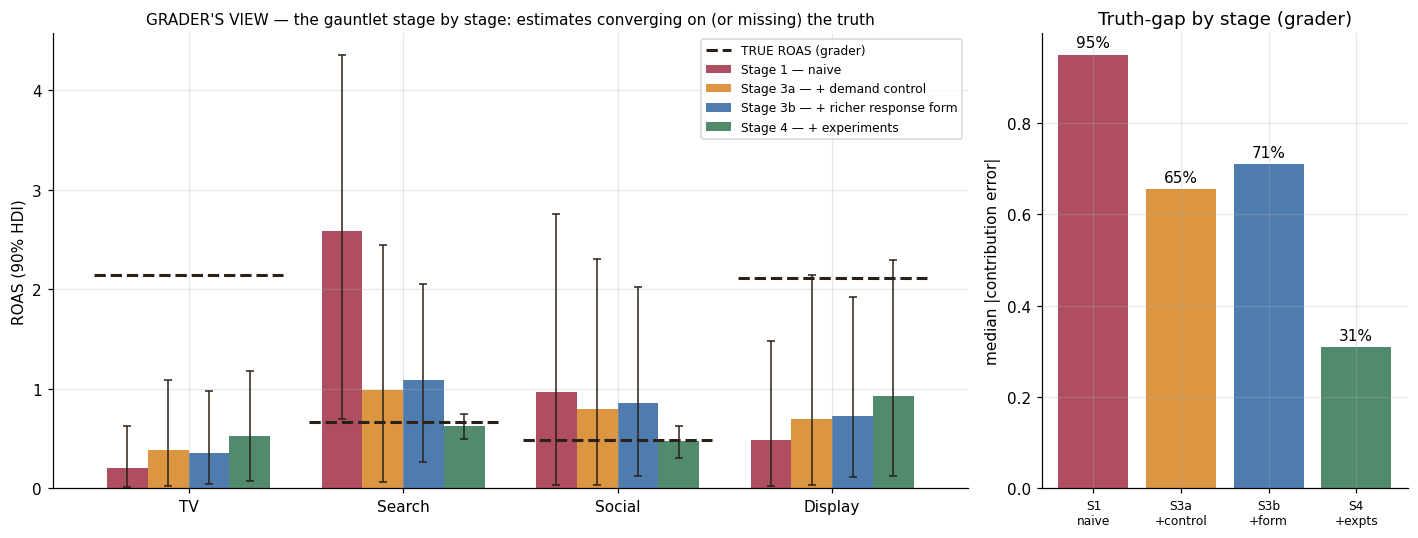

In [16]:
# THE CENTERPIECE — the whole drama in one figure: every stage's ROAS vs truth.
order = ["Stage 1 — naive", "Stage 3a — + demand control",
         "Stage 3b — + richer response form", "Stage 4 — + experiments"]
stage_cols = [BERRY, AMBER, SKY, LEAF]
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                              gridspec_kw={"width_ratios": [2.5, 1]})
x = np.arange(len(CHANNELS)); w = 0.19
for i, lbl in enumerate(order):
    tab = STAGES[lbl]["tab"]
    mids = tab["est ROAS"].to_numpy()
    err = np.clip(np.vstack([mids - tab["ROAS lo"], tab["ROAS hi"] - mids]), 0, None)
    ax.bar(x + (i - 1.5) * w, mids, w, yerr=err, capsize=2.5, color=stage_cols[i],
           alpha=0.9, error_kw=dict(ecolor=INK, lw=1.0), label=lbl)
for xi, c in enumerate(CHANNELS):
    ax.hlines(TRUE_ROAS[c], xi - 0.44, xi + 0.44, color=INK, ls="--", lw=2.0,
              label="TRUE ROAS (grader)" if xi == 0 else None)
ax.set_xticks(x); ax.set_xticklabels(CHANNELS); ax.set_ylabel("ROAS (90% HDI)")
ax.set_title("GRADER'S VIEW — the gauntlet stage by stage: estimates converging on "
             "(or missing) the truth", fontsize=10)
ax.legend(fontsize=8, loc="upper right")

med = [STAGES[lbl]["tab"]["contrib err"].abs().median() for lbl in order]
bars = ax2.bar(range(len(order)), med, color=stage_cols, alpha=0.9)
ax2.bar_label(bars, labels=[f"{v:.0%}" for v in med], padding=3)
ax2.set_xticks(range(len(order)))
ax2.set_xticklabels(["S1\nnaive", "S3a\n+control", "S3b\n+form", "S4\n+expts"], fontsize=8)
ax2.set_ylabel("median |contribution error|")
ax2.set_title("Truth-gap by stage (grader)")
plt.tight_layout(); plt.show()

> **🔭 GRADER'S BOX** — read the centerpiece left to right within each channel:
> **Search** is the red skyscraper that two structural pivots only
> half-demolished and one experiment leveled; **Social** is fixed by its
> experiment (and was nearly fixed by the form pivot — luck, not skill, as
> Search shows); **TV and Display** never move to the dashed line, because no
> amount of calibrating *other* channels — and no observational pivot —
> identifies a flat-spend, ~98%-mediated channel. The analyst never sees the
> dashed lines — but notice that the *one* analyst-visible feature that tracks
> the truth-gap is the interval width. Believe the width, not the midpoint.

## The fit-quality trap — four excellent fits, four different stories

If interval width is the analyst-visible signal that *works*, here is the
popular one that *doesn't*: how well the model traces the sales curve. Below
are the observed-vs-predicted **time series** for all four stages — posterior
mean over the observed sales, with the 90% posterior-predictive band. Every
stage of this notebook, from the demand-blind disaster to the
experiment-calibrated finale, produces a fit a slide deck would celebrate.

Output()

Output()

Output()

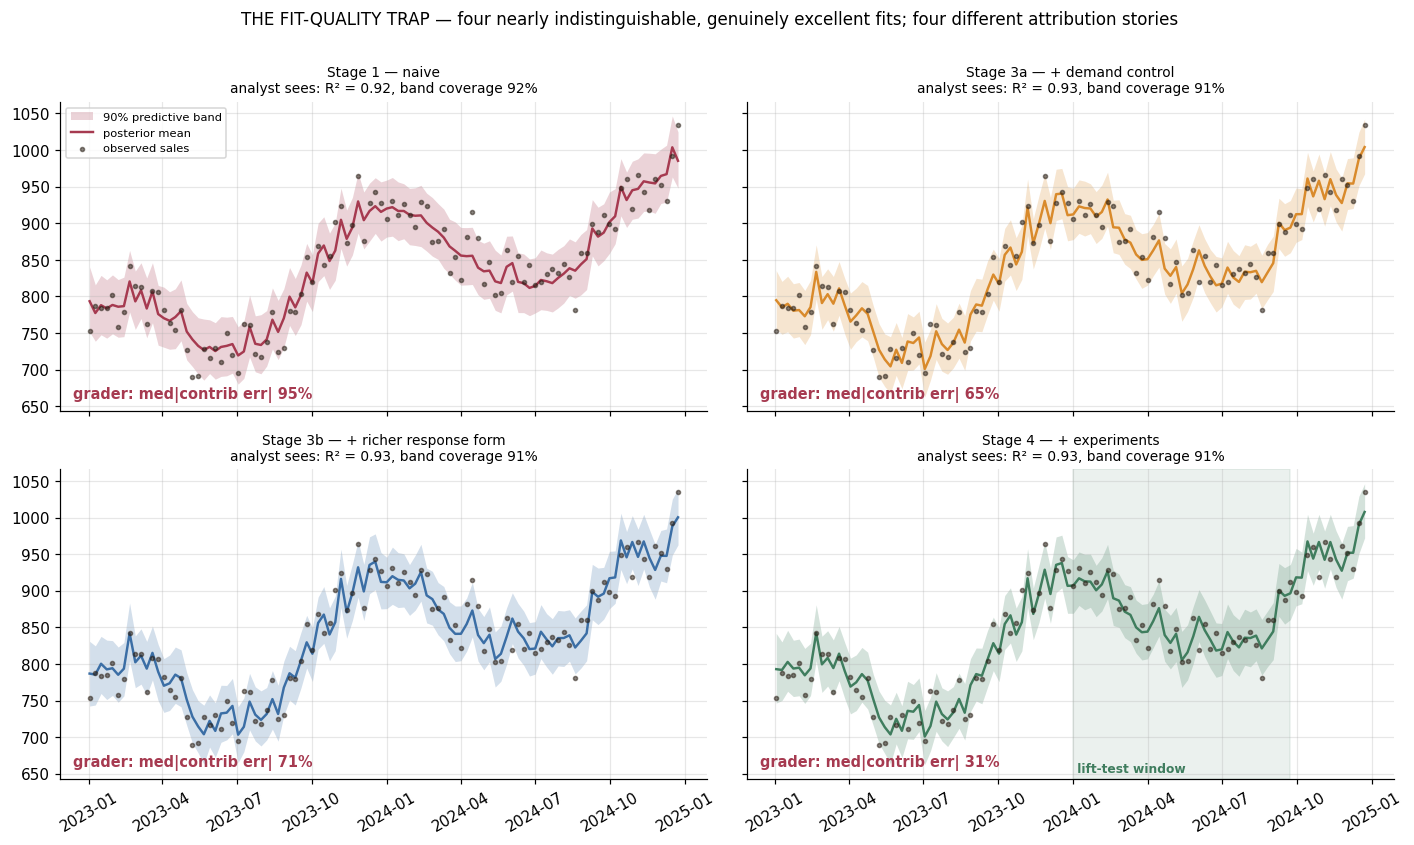

R² by stage:        0.918   0.930   0.929   0.927
[grader] med|err|:    95%     65%     71%     31%

Fit quality is REAL — the model is genuinely good at predicting what it can see —
and it moved by ~0.01 of R² across four specs whose attribution differs by 3x.
Fit quality and attribution identifiability are different axes. A predictive check
cannot choose between attribution stories that all predict the same curve.


In [17]:
# THE FIT-QUALITY TRAP — same four fitted models, no refitting: just predict().
for lbl in order:
    if "pred" not in STAGES[lbl]:
        with quiet():
            STAGES[lbl]["pred"] = STAGES[lbl]["model"].predict(
                return_original_scale=True, hdi_prob=0.90, random_seed=0)

fitstats = {}
fig, axes = plt.subplots(2, 2, figsize=(13, 7.6), sharex=True, sharey=True)
for ax, lbl, col in zip(axes.ravel(), order, stage_cols):
    pr = STAGES[lbl]["pred"]
    yhat = pr.y_pred_mean
    resid = y.to_numpy() - yhat
    r2 = 1 - resid.var() / y.to_numpy().var()
    cover = float(np.mean((y.to_numpy() >= pr.y_pred_hdi_low)
                          & (y.to_numpy() <= pr.y_pred_hdi_high)))
    fitstats[lbl] = {"r2": r2, "cover": cover,
                     "med": STAGES[lbl]["tab"]["contrib err"].abs().median()}
    ax.fill_between(aurora.weeks, pr.y_pred_hdi_low, pr.y_pred_hdi_high,
                    color=col, alpha=0.22, lw=0, label="90% predictive band")
    ax.plot(aurora.weeks, yhat, color=col, lw=1.6, label="posterior mean")
    ax.scatter(aurora.weeks, y, s=7, color=INK, alpha=0.55, label="observed sales", zorder=3)
    if lbl == order[-1]:
        ax.axvspan(pd.Timestamp(window[0]), pd.Timestamp(window[1]),
                   color=LEAF, alpha=0.10, zorder=0)
        ax.text(pd.Timestamp(window[0]), ax.get_ylim()[0] + 8, " lift-test window",
                color=LEAF, fontsize=8, fontweight="bold")
    ax.set_title(f"{lbl}\nanalyst sees: R² = {r2:.2f}, band coverage {cover:.0%}",
                 fontsize=9)
    ax.text(0.02, 0.04, f"grader: med|contrib err| {fitstats[lbl]['med']:.0%}",
            transform=ax.transAxes, color=BERRY, fontsize=9.5, fontweight="bold")
axes[0, 0].legend(fontsize=7.5, loc="upper left")
for ax in axes[1]:
    ax.tick_params(axis="x", labelrotation=30)
fig.suptitle("THE FIT-QUALITY TRAP — four nearly indistinguishable, genuinely excellent fits;"
             " four different attribution stories", fontsize=11, y=1.005)
plt.tight_layout(); plt.show()

r2v = {lbl: fitstats[lbl]["r2"] for lbl in order}
print("R² by stage:        " + "   ".join(f"{r2v[l]:.3f}" for l in order))
print("[grader] med|err|:  " + "   ".join(f"{fitstats[l]['med']:.0%}".rjust(5) for l in order))
assert min(r2v.values()) > 0.85, "every stage should fit the KPI excellently"
assert max(r2v.values()) - min(r2v.values()) < 0.05, "the four fits should be near-identical"
assert abs(r2v[order[0]] - r2v[order[-1]]) < 0.05, "naive and final R² within a few points"
assert all(0.75 <= fitstats[l]["cover"] <= 0.99 for l in order), "predictive bands well-calibrated"
assert fitstats[order[0]]["med"] > 2 * fitstats[order[-1]]["med"], \
    "attribution error differs hugely while fit quality does not"
print("\nFit quality is REAL — the model is genuinely good at predicting what it can see —")
print("and it moved by ~0.01 of R² across four specs whose attribution differs by 3x.")
print("Fit quality and attribution identifiability are different axes. A predictive check")
print("cannot choose between attribution stories that all predict the same curve.")

## Where the credit went — the decomposition, naive vs final

If all four models predict the same curve, what *differs* is who gets the
credit for it. `compute_component_decomposition()` splits the prediction into
baseline (intercept + trend + seasonality + controls) and per-channel media
wedges — additive by construction, so the panels below are the same sales
curve twice, carved up two ways.

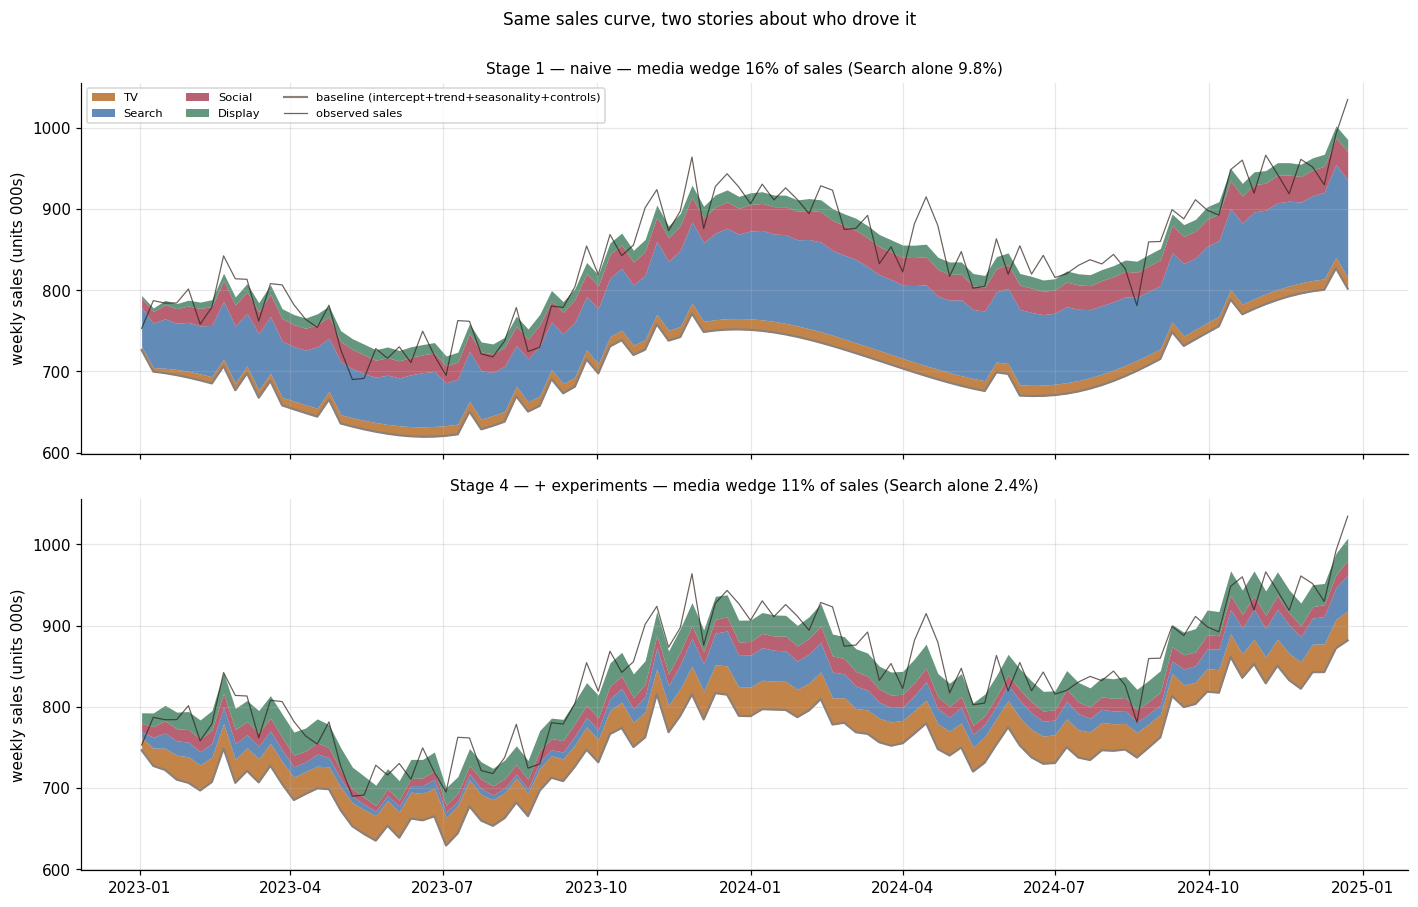

Search wedge: 9.8% of sales (naive) -> 2.4% (final).
Weekly wiggle that moved: std(Search media component) 18.7 -> 10.5; std(controls component) 14.6 -> 23.2.
The demand swings the naive model credited to Search's beta now flow through the
CategoryDemand control — same curve, the credit re-routed to the confounder.

[grader] TRUE total media share: 26%. Even the calibrated final model shows 11% —
[grader] the missing wedge is TV/Display's mediated effect, parked in the baseline
[grader] because a flat-spend, awareness-routed channel is invisible to this equation.


In [18]:
with quiet():
    dec1 = STAGES[order[0]]["model"].compute_component_decomposition()
    dec4 = STAGES[order[-1]]["model"].compute_component_decomposition()

fig, axes2 = plt.subplots(2, 1, figsize=(13, 8.2), sharex=True, sharey=True)
for ax, dec, lbl in ((axes2[0], dec1, order[0]), (axes2[1], dec4, order[-1])):
    base = dec.intercept + dec.trend + dec.seasonality + dec.controls_total
    media_sum = dec.media_by_channel.sum(axis=1).to_numpy()
    # additivity guard: components must rebuild the model's own prediction
    add_corr = np.corrcoef(base + media_sum, STAGES[lbl]["pred"].y_pred_mean)[0, 1]
    assert add_corr > 0.99, "decomposition must be additive to predict()"
    assert dec.media_by_channel.to_numpy().min() > 0, "media wedges stack on the baseline"
    bottom = base.copy()
    for c in CHANNELS:
        ax.fill_between(aurora.weeks, bottom, bottom + dec.media_by_channel[c].to_numpy(),
                        color=CHANNEL_COLORS[c], alpha=0.8, lw=0, label=c)
        bottom = bottom + dec.media_by_channel[c].to_numpy()
    ax.plot(aurora.weeks, base, color=MUTED, lw=1.4,
            label="baseline (intercept+trend+seasonality+controls)")
    ax.plot(aurora.weeks, y, color=INK, lw=0.8, alpha=0.7, label="observed sales")
    share = dec.media_by_channel.sum().sum() / y.sum()
    s_share = dec.media_by_channel["Search"].sum() / y.sum()
    ax.set_title(f"{lbl} — media wedge {share:.0%} of sales (Search alone {s_share:.1%})",
                 fontsize=10)
    ax.set_ylabel("weekly sales (units 000s)")
axes2[0].legend(fontsize=7.5, ncol=3, loc="upper left")
fig.suptitle("Same sales curve, two stories about who drove it", fontsize=11, y=1.0)
plt.tight_layout(); plt.show()

s1_search = dec1.media_by_channel["Search"].sum() / y.sum()
s4_search = dec4.media_by_channel["Search"].sum() / y.sum()
s1_media = dec1.media_by_channel.sum().sum() / y.sum()
s4_media = dec4.media_by_channel.sum().sum() / y.sum()
assert s1_search > 2 * s4_search, "the naive Search wedge should dwarf the final one"
assert s1_media > 1.2 * s4_media, "the naive media wedge should be the larger story"
assert dec4.controls_total.std() > 1.3 * dec1.controls_total.std(), \
    "the demand control's weekly wiggle should absorb what Search's beta carried"
assert dec1.media_by_channel["Search"].std() > 1.4 * dec4.media_by_channel["Search"].std()
print(f"Search wedge: {s1_search:.1%} of sales (naive) -> {s4_search:.1%} (final).")
print(f"Weekly wiggle that moved: std(Search media component) "
      f"{dec1.media_by_channel['Search'].std():.1f} -> {dec4.media_by_channel['Search'].std():.1f}; "
      f"std(controls component) {dec1.controls_total.std():.1f} -> {dec4.controls_total.std():.1f}.")
print("The demand swings the naive model credited to Search's beta now flow through the")
print("CategoryDemand control — same curve, the credit re-routed to the confounder.")
true_share = TRUE_CONTRIB.sum() / y.sum()
assert s4_media < true_share, "even the final model under-credits total media (grader)"
print(f"\n[grader] TRUE total media share: {true_share:.0%}. Even the calibrated final model "
      f"shows {s4_media:.0%} —")
print("[grader] the missing wedge is TV/Display's mediated effect, parked in the baseline")
print("[grader] because a flat-spend, awareness-routed channel is invisible to this equation.")

## The spec trajectory — what moves each number

One more way to see the whole arc: each channel's ROAS estimate as the spec
evolves, 90% HDI as whiskers. The analyst sees the solid lines and whiskers —
*how much the answer moves when reasonable people change the spec* — and the
grader's dashed truth line says who was actually close.

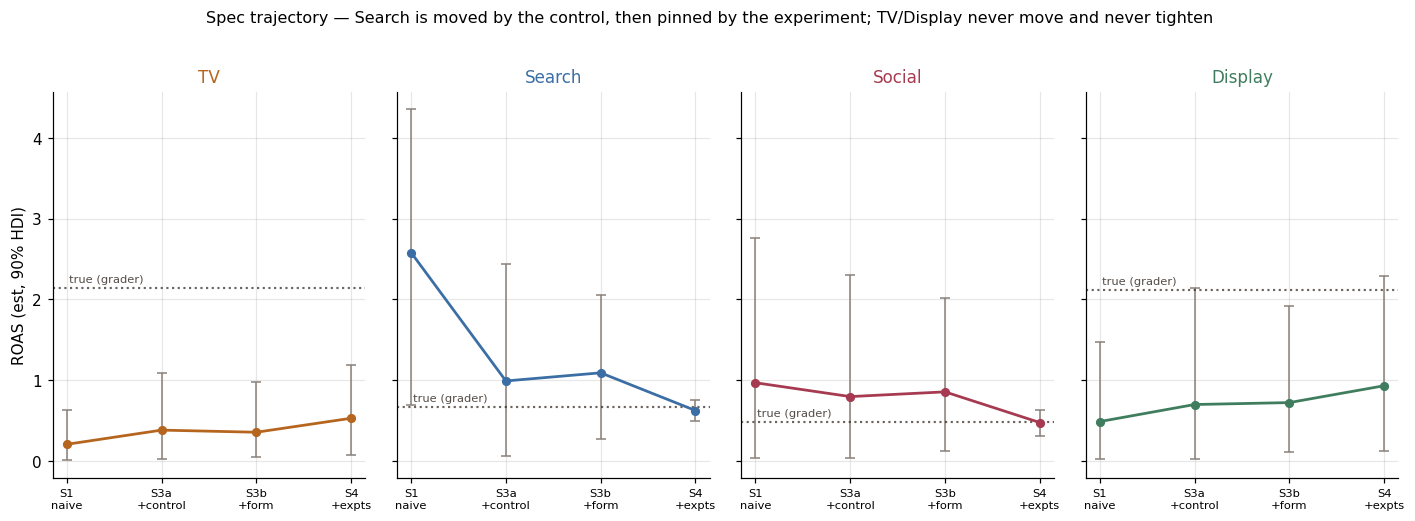

Search across observational specs: 2.58 -> 0.99 -> 1.09 — a >2x range from defensible spec choices alone.
ANALYST RULE OF THUMB: a number that moves this much across reasonable specs is not
a measurement yet; the trajectory only stops moving where randomized evidence lands.
[grader] every TV estimate sat below 0.53 while the truth is 2.14 — the dashed line no observational spec can reach.


In [19]:
xs = np.arange(len(order))
xticklbls = ["S1\nnaive", "S3a\n+control", "S3b\n+form", "S4\n+expts"]
fig, axes3 = plt.subplots(1, 4, figsize=(13, 4.6), sharex=True, sharey=True)
for ax, c in zip(axes3, CHANNELS):
    mids = np.array([STAGES[l]["tab"].loc[c, "est ROAS"] for l in order])
    los = np.array([STAGES[l]["tab"].loc[c, "ROAS lo"] for l in order])
    his = np.array([STAGES[l]["tab"].loc[c, "ROAS hi"] for l in order])
    yerr = np.clip(np.vstack([mids - los, his - mids]), 0, None)
    ax.errorbar(xs, mids, yerr=yerr,
                color=CHANNEL_COLORS[c], marker="o", ms=5, lw=1.8, capsize=3,
                ecolor=MUTED, elinewidth=1.0)
    ax.axhline(TRUE_ROAS[c], color=INK, ls=":", lw=1.4, alpha=0.7)
    ax.text(0.02, TRUE_ROAS[c] + 0.07, "true (grader)", fontsize=7.5, color=INK, alpha=0.8)
    ax.set_xticks(xs); ax.set_xticklabels(xticklbls, fontsize=7.5)
    ax.set_title(c, color=CHANNEL_COLORS[c], fontsize=11)
axes3[0].set_ylabel("ROAS (est, 90% HDI)")
fig.suptitle("Spec trajectory — Search is moved by the control, then pinned by the experiment;"
             " TV/Display never move and never tighten", fontsize=10.5, y=1.02)
plt.tight_layout(); plt.show()

search_obs = [STAGES[l]["tab"].loc["Search", "est ROAS"] for l in order[:3]]
assert max(search_obs) / min(search_obs) > 2, \
    "across observational specs alone, Search's estimate more than halves/doubles"
tv_ests = [STAGES[l]["tab"].loc["TV", "est ROAS"] for l in order]
assert max(tv_ests) < 1.0 and TRUE_ROAS["TV"] > 2 * max(tv_ests), \
    "(grader) no spec ever lifts TV anywhere near its truth"
print(f"Search across observational specs: {search_obs[0]:.2f} -> {search_obs[1]:.2f} -> "
      f"{search_obs[2]:.2f} — a >2x range from defensible spec choices alone.")
print("ANALYST RULE OF THUMB: a number that moves this much across reasonable specs is not")
print("a measurement yet; the trajectory only stops moving where randomized evidence lands.")
print(f"[grader] every TV estimate sat below {max(tv_ests):.2f} while the truth is "
      f"{TRUE_ROAS['TV']:.2f} — the dashed line no observational spec can reach.")

---
# Stage 5 — The deliverable

What can the analyst now put in front of a CFO, and on what evidence? First,
the evolution of the only honest currency the analyst has — interval width:

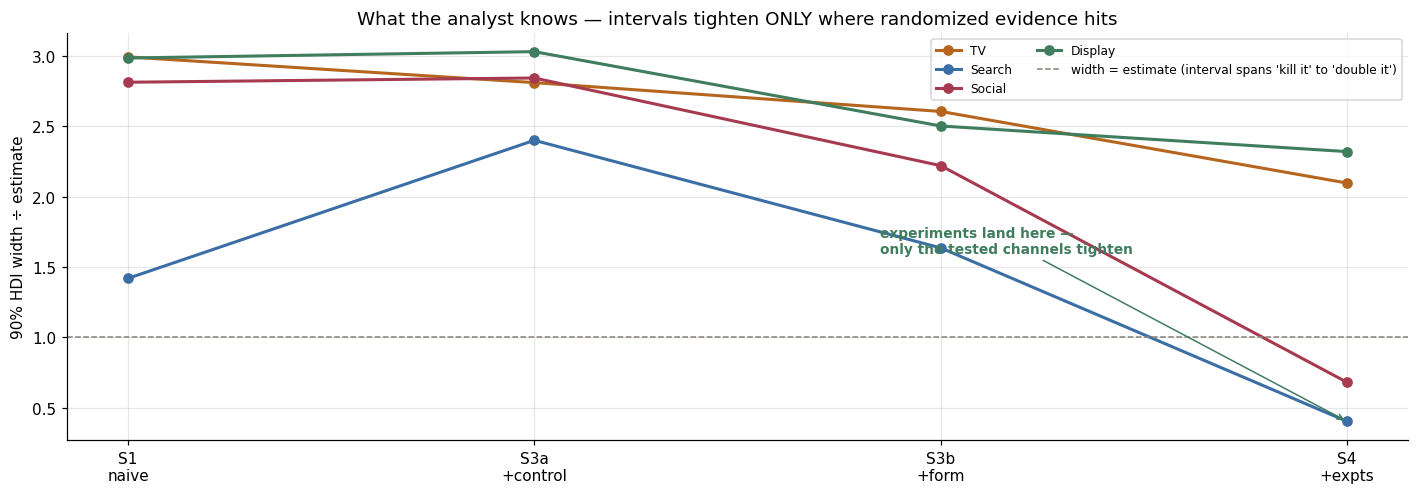

Relative width at the final stage: {'TV': 2.1, 'Search': 0.4, 'Social': 0.68, 'Display': 2.32}
Two channels earned tight intervals by being randomized; two are wide and stay wide.
This figure IS the deliverable's spine: knowledge is where the whiskers are short.


In [20]:
# What the analyst KNOWS, stage by stage: relative interval width (width ÷ estimate).
relw = pd.DataFrame({lbl: (STAGES[lbl]["tab"]["ROAS hi"] - STAGES[lbl]["tab"]["ROAS lo"])
                     / STAGES[lbl]["tab"]["est ROAS"] for lbl in order}).loc[CHANNELS]
fig, ax = plt.subplots(figsize=(13, 4.6))
for c in CHANNELS:
    ax.plot(xs, relw.loc[c], color=CHANNEL_COLORS[c], marker="o", ms=6, lw=2, label=c)
ax.set_xticks(xs); ax.set_xticklabels(xticklbls)
ax.set_ylabel("90% HDI width ÷ estimate")
ax.axhline(1.0, color=MUTED, ls="--", lw=1,
           label="width = estimate (interval spans 'kill it' to 'double it')")
ax.annotate("experiments land here —\nonly the tested channels tighten",
            xy=(3, float(relw.loc["Search", order[-1]])), xytext=(1.85, 1.6),
            fontsize=9, color=LEAF, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=LEAF))
ax.set_title("What the analyst knows — intervals tighten ONLY where randomized evidence hits")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

assert relw.loc[["TV", "Display"]].min(axis=1).min() > 1.5, \
    "TV/Display intervals stay >1.5x their estimates at EVERY stage"
assert relw.loc["Search", order[-1]] < 0.9 and relw.loc["Social", order[-1]] < 1.0
assert relw.loc["Search", order[2]] > 2 * relw.loc["Search", order[-1]], \
    "the experiment, not the spec work, is what tightened Search"
print("Relative width at the final stage:", relw[order[-1]].round(2).to_dict())
print("Two channels earned tight intervals by being randomized; two are wide and stay wide.")
print("This figure IS the deliverable's spine: knowledge is where the whiskers are short.")

In [21]:
# The table that goes in front of the CFO contains ONLY analyst-visible columns.
deliver = t4[["est ROAS", "ROAS lo", "ROAS hi"]].copy().round(2)
deliver["evidence"] = ["observational (mediated, flat spend)", "lift test + model",
                       "lift test + model", "observational (mediated, flat spend)"]
deliver["status"] = ["NOT IDENTIFIED — do not quote a point", "calibrated — shippable",
                     "calibrated — shippable", "NOT IDENTIFIED — do not quote a point"]
deliver["next evidence to buy"] = [
    "TV regional weight test (long window for carryover) + nested/mediation model (stress_04)",
    "re-test next planning cycle (drift)",
    "re-test next planning cycle (drift)",
    "Display geo-holdout; share mediation model with TV",
]
display(deliver)
rel_width = ((t4["ROAS hi"] - t4["ROAS lo"]) / t4["est ROAS"]).round(1)
print("Relative HDI width (interval ÷ estimate):", rel_width.to_dict())
print("Every 'status' above is justified by a number in this table or an experiment receipt —")
print("no truth access anywhere in the deliverable.")
print("\n[grader] scoring the deliverable: truth in 90% HDI -> "
      + ", ".join(f"{c}: {t4.loc[c, 'true in 90% HDI']}" for c in CHANNELS))
print("[grader] The calibrated channels are right AND tight. TV's interval misses the truth —")
print("[grader] which is exactly why the analyst's 'do not quote a point' status (rather than")
print("[grader] 'trust the interval') is the defensible call for an unidentified channel.")

,est ROAS,ROAS lo,ROAS hi,evidence,status,next evidence to buy
TV,0.53,0.08,1.18,"observational (mediated, flat spend)",NOT IDENTIFIED — do not quote a point,TV regional weight test (long window for carry...
Search,0.62,0.50,0.75,lift test + model,calibrated — shippable,re-test next planning cycle (drift)
Social,0.48,0.30,0.63,lift test + model,calibrated — shippable,re-test next planning cycle (drift)
Display,0.93,0.13,2.29,"observational (mediated, flat spend)",NOT IDENTIFIED — do not quote a point,Display geo-holdout; share mediation model wit...


Relative HDI width (interval ÷ estimate): {'TV': 2.1, 'Search': 0.4, 'Social': 0.7, 'Display': 2.3}
Every 'status' above is justified by a number in this table or an experiment receipt —
no truth access anywhere in the deliverable.

[grader] scoring the deliverable: truth in 90% HDI -> TV: ✗, Search: ✓, Social: ✓, Display: ✓
[grader] The calibrated channels are right AND tight. TV's interval misses the truth —
[grader] which is exactly why the analyst's 'do not quote a point' status (rather than
[grader] 'trust the interval') is the defensible call for an unidentified channel.


**What the analyst can defensibly say** — every clause backed by an observable
in this notebook:

- *"Search and Social ROAS are ≈0.65 and ≈0.49, calibrated against randomized
  holdouts, with tight intervals — both return well under a dollar per dollar.
  The incremental case for the current Search/Social budget is weak."*
  (Evidence: the lift-test receipts plus post-calibration intervals.)
- *"TV's effect is not identified by this data: its 90% interval spans several
  times its estimate, its point estimate drifted across every reasonable spec
  we ran, its spend has barely varied in two years, and its hypothesized
  pathway (awareness) is one this model cannot see. We will not quote a
  midpoint in either direction. Here is the experiment that resolves it, and
  its cost."* (Evidence: the interval-width and spec-trajectory figures —
  same statement for Display.)
- The *direction* of the budget implication — the channels whose estimates
  survived randomized testing return under a dollar per dollar, so money is
  likely misallocated toward the demand-chasing channels — and that the same
  analysis on the full Aurora showcase (all four channels experiment-anchored,
  [05_unified_workflow](05_unified_workflow.ipynb)) values correcting that
  misallocation at **seven figures a year**.

**What they must NOT say:**

- ~~"TV has a ROAS of 0.55"~~ — a midpoint from an unidentified posterior is a
  coin flip wearing a decimal point.
- ~~"TV doesn't work — cut it"~~ — the Stage-1 conclusion. *Absence of
  identification is not absence of effect* — the analyst's own interval and
  spec-trajectory say "unknown", not "zero".
- ~~"The model is validated: r-hat is clean, the PPC passes, R² is 0.92"~~ —
  every one of those was equally true of the naive fit. The fit-quality trap
  is the slide most likely to mislead a boardroom.
- Any reallocation *sized* from the TV/Display point estimates — only the
  experiment-backed channels and the test plan are actionable.

> **🔭 GRADER'S BOX** — scoring those refusals: TV's true ROAS is ~2.1, so the
> forbidden sentence "TV doesn't work — cut it" would have severed the
> company's single best channel on the word of an unidentified posterior. The
> analyst never knew that number — and didn't need to: the refusal was carried
> entirely by the width of an interval and the wobble of a spec trajectory.

---
# The decision table — the series in one artifact

Symptom → likely cause(s) → cheapest check → pivot → where it's demonstrated.
This is the table to copy out of the series.

| # | SYMPTOM | LIKELY CAUSE(S) | CHEAP CHECK | PIVOT | NOTEBOOK |
|---|---|---|---|---|---|
| 1 | Divergences / r-hat > 1.01 | model fighting the data (misspec, conflict-laden priors) — not merely a tuning problem | where do divergent draws sit? does the conflict survive `target_accept` 0.95? | triage params (learning, pairs) **before** re-tuning; fix the structure the conflict points at | stress_00 · **05** |
| 2 | One channel's HDI ≫ its estimate | weak/flat spend (low CoV) — intercept-confounded | CoV < ~0.3? | report the interval, or buy an experiment; no model rescues a flat series | stress_00 · walkthrough |
| 3 | Two channels' HDIs huge **and** their spends correlated | collinearity — combined effect identified, split isn't | spend corr > ~0.9 / VIF > 10 | group them, or lift-test one to anchor the split | stress_03 |
| 4 | PPC fails (shape/autocorrelation) | missing time structure: trend break, seasonality, carryover misspec | plot residuals over time & by season | richer trend/seasonality/adstock — then re-check | stress_02 · stress_01 |
| 5 | PPC **passes** | — certifies fit, not attribution | (none — that's the point) | never read green PPC as causal validation | stress_00 |
| 6 | RV low on a channel | estimate nullified by a mild confounder | does a candidate confounder that strong exist? | find/keep the proxy control; calibrate | stress_03 |
| 7 | RV high but a plausible confounder is *known* | RV measures required strength, not existence | corr(spend, proxy), corr(proxy, KPI) | control the proxy regardless; RV is no green light | **05** (Search) |
| 8 | Parameter prior-dominated (contraction ≈ 0, overlap ≈ 1) | data carries no information (flat, collinear, short window) | CoV, spend corr, window length | experiment, or own the prior in the writeup | stress_00 |
| 9 | **Negative contraction** + big shift_z | prior-data conflict — often confounding demanding an absurd effect | corr(spend, demand proxy) | close the back-door; if it persists, calibrate | stress_03 · **05** |
| 10 | Estimate piled on the sign constraint (β ≈ 0 under a positive prior) | true effect negative (cannibalization) or mediated-away | cross-product/holdout correlations; mediator inventory | allow the sign / model the cross-effect or mediation explicitly | stress_04 |
| 11 | Spend max/median ≫ ~8 | data-entry spike or one-off burst → normalization trap | max/median screen | verify, winsorize/cap, percentile-normalize | stress_01 |
| 12 | KPI level break | regime change a constant-coefficient MMM can't absorb | plot the KPI; ask the business what happened | dummy/piecewise trend; never let media absorb a break | stress_02 |
| 13 | Holiday-shaped residuals | seasonality misspec | residuals by week-of-year | holiday terms / higher Fourier order | stress_02 |
| 14 | ROAS that would make the channel the best investment the company owns | demand confounding, mirage by construction | corr(spend, demand proxy); benchmark sanity | treat as confounded until an experiment says otherwise | stress_03 · **05** |
| 15 | naive corr(spend, KPI) ≫ any plausible ROAS | spend chases demand — the dashboard mirage | the Stage-0 mirage table | the proxy control is mandatory; calibrate the channel | **05** (Stage 0) |

### The pre-specification doctrine

Every pivot above was *available to be chosen after seeing ROAS* — which is how
motivated reasoning ships. The discipline that survived this notebook:

1. **Lock the spec before looking at ROAS**: causal roles (confounder /
   precision / mediator / collider), functional forms, priors, and which
   channels get calibrated — all decided from EDA + DAG + institutional
   knowledge, in writing, before the first attribution is read.
2. **Pivot only on diagnostics, not on disliked answers** — each stage above
   was triggered by a measured symptom (conflict, prior-domination, ceiling),
   never by "Search looks too high for my taste".
3. **What always escalates to an experiment**: a flat-spend channel (CoV ≲
   0.3); a channel whose spend tracks a demand signal; a collinear pair that
   matters; any channel about to receive a large budget move. Observational
   pivots change the answer; only randomization *identifies* it.

---
# What to remember

Each lesson below is stated the way a field analyst could state it — from
observables — with the grader's confirmation in parentheses.

1. **EDA caught it first.** The mirage table (naive corr 0.85 vs any plausible
   ROAS), the CoV screen, and the DAG flagged every failure this notebook hit
   — *before sampling*. The cheapest diagnostics run before the model exists.
2. **Alarm volume is not failure size.** The 2026-06-08 recording of this
   world screamed (108 divergences); later re-recordings and our run are an
   order of magnitude quieter. (Grader: the attribution was ~90% wrong every
   time.) Loud alarms mean *stop*; quiet ones certify nothing.
3. **Fit quality is not attribution.** Four specs, R² ≈ 0.92 each, predictive
   bands indistinguishable to the eye — the analyst cannot tell them apart by
   fit, and shouldn't try. (Grader: their truth-gaps spanned 95% → 31%.) The
   model is genuinely good at predicting what it can see; what it can see is
   not the causal question.
4. **Controlled ≠ identified.** Adding the demand proxy moved the headline
   channel by ~60% — and the interval that came back still spanned the whole
   decision space, because collinearity with the confounder leaves almost no
   independent variation to learn from. (Grader: a +50% overstatement
   remained.) stress_03's lesson, at full scale.
5. **Spec sensitivity is an instrument — point it at your own model.** A much
   richer response family moved every estimate ≤ ~10% and improved nothing
   observable: the spec, not the data, was choosing the numbers. (Grader: that
   "richer" family was the DGP's *exact* truth, and the headline error still
   drifted worse — form pivots reshuffle bias under unresolved confounding.)
6. **Experiments end arguments — exactly where they're aimed.** Two lift tests
   gave Search and Social tight, randomization-anchored intervals; TV and
   Display's widths didn't move, because calibration is not contagious.
   (Grader: the calibrated pair landed on the truth; the headline error fell
   by two-thirds.)
7. **The deliverable is the honest split**: experiment-backed numbers, wide
   intervals owned as wide — *"not identified" said out loud* — and a costed
   test plan for the rest. Never the full table of midpoints.

**The series, in one sentence:** the model converging is the beginning of the
question, not the end of it.

**And the capstone's own sentence:** the grader's box does not exist in the
field — so the intervals, the spec trajectories, and the experiments you buy
*are* the truth you get to have.

Pointers: [stress_00](stress_00_the_rosy_picture.ipynb) ·
[stress_01](stress_01_carryover_and_shape.ipynb) ·
[stress_02](stress_02_time_structure.ipynb) ·
[stress_03](stress_03_confounding_and_selection.ipynb) ·
[stress_04](stress_04_extension_traps.ipynb) ·
[mmm_walkthrough](mmm_walkthrough.ipynb) (the same workflow on a tamer
realistic world) · `tests/synth/` (the stress matrix this series is built on) ·
[math_05](math_05_calibration.ipynb) (the calibration algebra).